### Load in Protein Data

In [8]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
# expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values
adata.obsm["X_umap"] = umap.values

### Analysis of co-localization spatial matrix

On some of the samples I noticed that some of the PMN cells have low colocalization with other immmune cells despite being close (but maybe not touching) geographically. 

This contains analysis of PMN cell interaction. Namly
* How many cells are considering interacting with PMNs on average
* What types of cells do PMNs iteract with
* The potential of changing to a radial plot

Notes: 
* Interestinly the delaunay method only seems to show the 6 nearest cells. Allways just slightly below that number. 

### Neighbooring Cell Percentages 

Function which loops the the cell types neighbooring each PMN. Spits out a results like (60% fibroblast 15% CD8 cells 15% Tumor 10% Other)

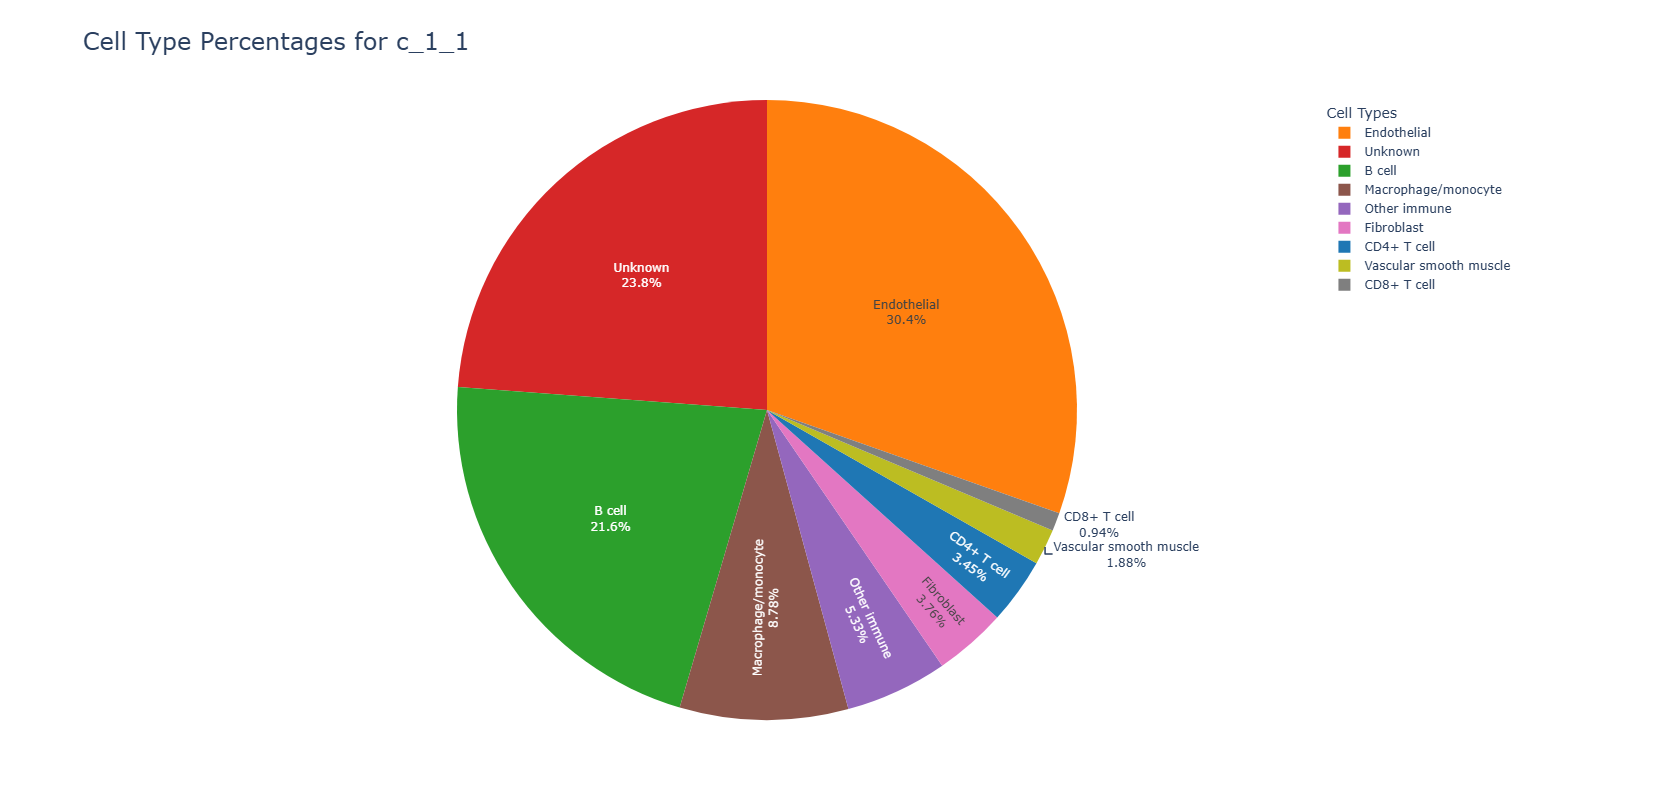

,CD4+ T cell,B cell,Endothelial,Unknown,Other immune,Macrophage/monocyte,Fibroblast,Vascular smooth muscle,CD8+ T cell
Sample ID,,,,,,,,,
c_1_1,3.448276,21.630094,30.407524,23.824451,5.329154,8.777429,3.761755,1.880878,0.940439


,CD4+ T cell,B cell,Endothelial,Unknown,Other immune,Macrophage/monocyte,Fibroblast,Vascular smooth muscle,CD8+ T cell,Total Cell Count
Sample ID,,,,,,,,,,
c_1_1,11,69,97,76,17,28,12,6,3,319


In [4]:
import my_functions

# Initialize an empty DataFrame to collect all percentage rows
all_percentages = pd.DataFrame()
all_total_counts = pd.DataFrame()

for i in range(1,2):
    for j in range(1,2):

        # check to make sure PMNs are present, skips if not present to prevent errors
        pmn_count=my_functions.pmn_counter(adata, f"c_{i}_{j}_")["PMN Count"]
        if pmn_count<1:
            continue

        # Calculate cell counts and percentages
        results = my_functions.average_cell_counts(adata, i, j, "delaunay",200)

        # Append the percentage row to the overall DataFrame
        all_percentages = pd.concat([all_percentages, results["Cell Type Percentages"]])
        all_total_counts = pd.concat([all_total_counts, results["Total Cell Counts"]])

        # Replaces Nans with 0 to pererve the numerical type of the matrix
        all_percentages.fillna(0, inplace=True)
        all_total_counts.fillna(0, inplace=True)

        my_functions.plot_cell_type_pie(f"c_{i}_{j}",all_percentages)

display(all_percentages)
display(all_total_counts)

### Responder and Non-Responder Cell Neighboors Pie Chart

I want to see how the cellular neighborhood differs between responder and non responder cells. The z-scores were non conclusive and there is likely heavy tissue differences making statistical analysis hard but it will be a useful visual.

In [29]:
import my_functions

# Initialize an empty DataFrame to collect all percentage rows
all_percentages = pd.DataFrame()
all_total_counts_R = pd.DataFrame()
all_total_counts_NR = pd.DataFrame()
for i in range(1,4):
    for j in range(1,26):

        # check to make sure PMNs are present, skips if not present to prevent errors
        pmn_count=my_functions.pmn_counter(adata, f"c_{i}_{j}_")["PMN Count"]
        if pmn_count<1:
            continue

        # Calculate cell counts and percentages
       # results = my_functions.average_cell_counts(adata, i, j, "radius", 125)
        results = my_functions.average_cell_counts(adata, i, j, "delaunay", 125)
    
        # Append the percentage row to the overall DataFrame
        if my_functions.get_sample_info(adata,f"c_{i}_{j}_")["Response"]=="R":
            all_total_counts_R = pd.concat([all_total_counts_R, results["Total Cell Counts"]])
        elif my_functions.get_sample_info(adata,f"c_{i}_{j}_")["Response"]=="NR":
            all_total_counts_NR = pd.concat([all_total_counts_NR, results["Total Cell Counts"]])

        # Replaces Nans with 0 to pererve the numerical type of the matrix
        all_total_counts_R.fillna(0, inplace=True)
        all_total_counts_NR.fillna(0, inplace=True)

#display(all_percentages)
display(all_total_counts_R)
display(all_total_counts_NR)

,Neutrophils,Monocytes,Endothelial_cells,Plasma_cells,Tumor_cells,Fibroblasts/SMCs,Macrophages,B_cells,CD4+T_cells,Total Cell Count,Tregs,DCs,CD8+T_cells,NK_cells
Sample ID,,,,,,,,,,,,,,
c_1_1,106.0,7.0,81.0,39,64,16,4.0,1.0,1.0,319,0.0,0.0,0.0,0.0
c_1_3,2.0,1.0,10.0,2,17,6,1.0,0.0,1.0,40,0.0,0.0,0.0,0.0
c_1_4,4.0,2.0,30.0,3,13,10,2.0,3.0,6.0,79,2.0,4.0,0.0,0.0
c_1_5,16.0,2.0,21.0,6,18,21,3.0,0.0,0.0,90,0.0,2.0,1.0,0.0
c_1_6,48.0,0.0,7.0,17,4,36,0.0,2.0,12.0,127,1.0,0.0,0.0,0.0
c_1_10,0.0,0.0,0.0,5,8,40,1.0,0.0,1.0,55,0.0,0.0,0.0,0.0
c_1_11,96.0,84.0,0.0,39,180,107,102.0,16.0,26.0,718,7.0,34.0,27.0,0.0
c_1_12,24.0,5.0,0.0,8,92,34,18.0,7.0,17.0,237,3.0,9.0,20.0,0.0
c_1_13,66.0,8.0,0.0,1,93,15,4.0,0.0,9.0,210,1.0,12.0,1.0,0.0


,Tumor_cells,Endothelial_cells,Plasma_cells,Fibroblasts/SMCs,Monocytes,Total Cell Count,CD4+T_cells,Macrophages,CD8+T_cells,Neutrophils,DCs,B_cells,Tregs,NK_cells
Sample ID,,,,,,,,,,,,,,
c_1_7,11,13.0,1.0,1,1.0,27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_1_8,7,88.0,6.0,3,5.0,162,3.0,28.0,10.0,10.0,2.0,0.0,0.0,0.0
c_1_9,159,0.0,8.0,48,16.0,320,0.0,17.0,0.0,64.0,6.0,2.0,0.0,0.0
c_1_17,48,0.0,32.0,23,8.0,259,14.0,13.0,4.0,56.0,58.0,0.0,3.0,0.0
c_1_18,551,0.0,84.0,367,162.0,2659,78.0,158.0,97.0,1066.0,59.0,16.0,21.0,0.0
c_1_19,518,0.0,66.0,381,223.0,2397,33.0,223.0,38.0,750.0,143.0,10.0,11.0,1.0
c_1_22,148,0.0,21.0,120,30.0,580,29.0,40.0,44.0,108.0,26.0,7.0,7.0,0.0
c_1_23,129,0.0,0.0,48,2.0,248,0.0,19.0,0.0,50.0,0.0,0.0,0.0,0.0
c_1_25,44,0.0,39.0,83,35.0,482,41.0,57.0,50.0,62.0,49.0,17.0,4.0,1.0


In [30]:
# Drop 'Total Cell Count' column before calculating totals
all_total_counts_R = all_total_counts_R.drop("Total Cell Count", axis=1)
all_total_counts_NR = all_total_counts_NR.drop("Total Cell Count", axis=1)

# Create totals row (summing numeric columns)
totals_R = all_total_counts_R.sum(numeric_only=True)
totals_NR = all_total_counts_NR.sum(numeric_only=True)
totals_R.name = 'Total'  # Name the row index
totals_NR.name = 'Total'  # Name the row index

# Append the totals row to the original DataFrame
all_total_counts_R = pd.concat([all_total_counts_R, totals_R.to_frame().T])
all_total_counts_NR = pd.concat([all_total_counts_NR, totals_NR.to_frame().T])

# Create percent row: each column’s value as a percent of the grand total
percent_R = (totals_R / totals_R.sum()) * 100
percent_NR = (totals_NR / totals_NR.sum()) * 100
percent_R.name = 'Percent Responder'
percent_NR.name = 'Percent Non Responder'

# Round to 1 decimal place (optional)
percent_R = percent_R.round(3)
percent_NR = percent_NR.round(3)

# Append percent row
all_total_counts_R = pd.concat([all_total_counts_R, percent_R.to_frame().T])
all_total_counts_NR = pd.concat([all_total_counts_NR, percent_NR.to_frame().T])

# Display results
display(all_total_counts_R)
display(all_total_counts_NR)

,Neutrophils,Monocytes,Endothelial_cells,Plasma_cells,Tumor_cells,Fibroblasts/SMCs,Macrophages,B_cells,CD4+T_cells,Tregs,DCs,CD8+T_cells,NK_cells
c_1_1,106.000,7.000,81.000,39.000,64.000,16.00,4.000,1.000,1.000,0.000,0.000,0.00,0.000
c_1_3,2.000,1.000,10.000,2.000,17.000,6.00,1.000,0.000,1.000,0.000,0.000,0.00,0.000
c_1_4,4.000,2.000,30.000,3.000,13.000,10.00,2.000,3.000,6.000,2.000,4.000,0.00,0.000
c_1_5,16.000,2.000,21.000,6.000,18.000,21.00,3.000,0.000,0.000,0.000,2.000,1.00,0.000
c_1_6,48.000,0.000,7.000,17.000,4.000,36.00,0.000,2.000,12.000,1.000,0.000,0.00,0.000
c_1_10,0.000,0.000,0.000,5.000,8.000,40.00,1.000,0.000,1.000,0.000,0.000,0.00,0.000
c_1_11,96.000,84.000,0.000,39.000,180.000,107.00,102.000,16.000,26.000,7.000,34.000,27.00,0.000
c_1_12,24.000,5.000,0.000,8.000,92.000,34.00,18.000,7.000,17.000,3.000,9.000,20.00,0.000
c_1_13,66.000,8.000,0.000,1.000,93.000,15.00,4.000,0.000,9.000,1.000,12.000,1.00,0.000
c_1_14,0.000,9.000,0.000,1.000,4.000,24.00,4.000,0.000,5.000,0.000,1.000,0.00,0.000


,Tumor_cells,Endothelial_cells,Plasma_cells,Fibroblasts/SMCs,Monocytes,CD4+T_cells,Macrophages,CD8+T_cells,Neutrophils,DCs,B_cells,Tregs,NK_cells
c_1_7,11.00,13.000,1.000,1.000,1.000,0.0,0.000,0.000,0.000,0.00,0.000,0.000,0.000
c_1_8,7.00,88.000,6.000,3.000,5.000,3.0,28.000,10.000,10.000,2.00,0.000,0.000,0.000
c_1_9,159.00,0.000,8.000,48.000,16.000,0.0,17.000,0.000,64.000,6.00,2.000,0.000,0.000
c_1_17,48.00,0.000,32.000,23.000,8.000,14.0,13.000,4.000,56.000,58.00,0.000,3.000,0.000
c_1_18,551.00,0.000,84.000,367.000,162.000,78.0,158.000,97.000,1066.000,59.00,16.000,21.000,0.000
c_1_19,518.00,0.000,66.000,381.000,223.000,33.0,223.000,38.000,750.000,143.00,10.000,11.000,1.000
c_1_22,148.00,0.000,21.000,120.000,30.000,29.0,40.000,44.000,108.000,26.00,7.000,7.000,0.000
c_1_23,129.00,0.000,0.000,48.000,2.000,0.0,19.000,0.000,50.000,0.00,0.000,0.000,0.000
c_1_25,44.00,0.000,39.000,83.000,35.000,41.0,57.000,50.000,62.000,49.00,17.000,4.000,1.000
c_2_1,118.00,2.000,9.000,35.000,18.000,5.0,5.000,7.000,24.000,5.00,5.000,2.000,0.000


[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 15718 bytes to my_functions.py


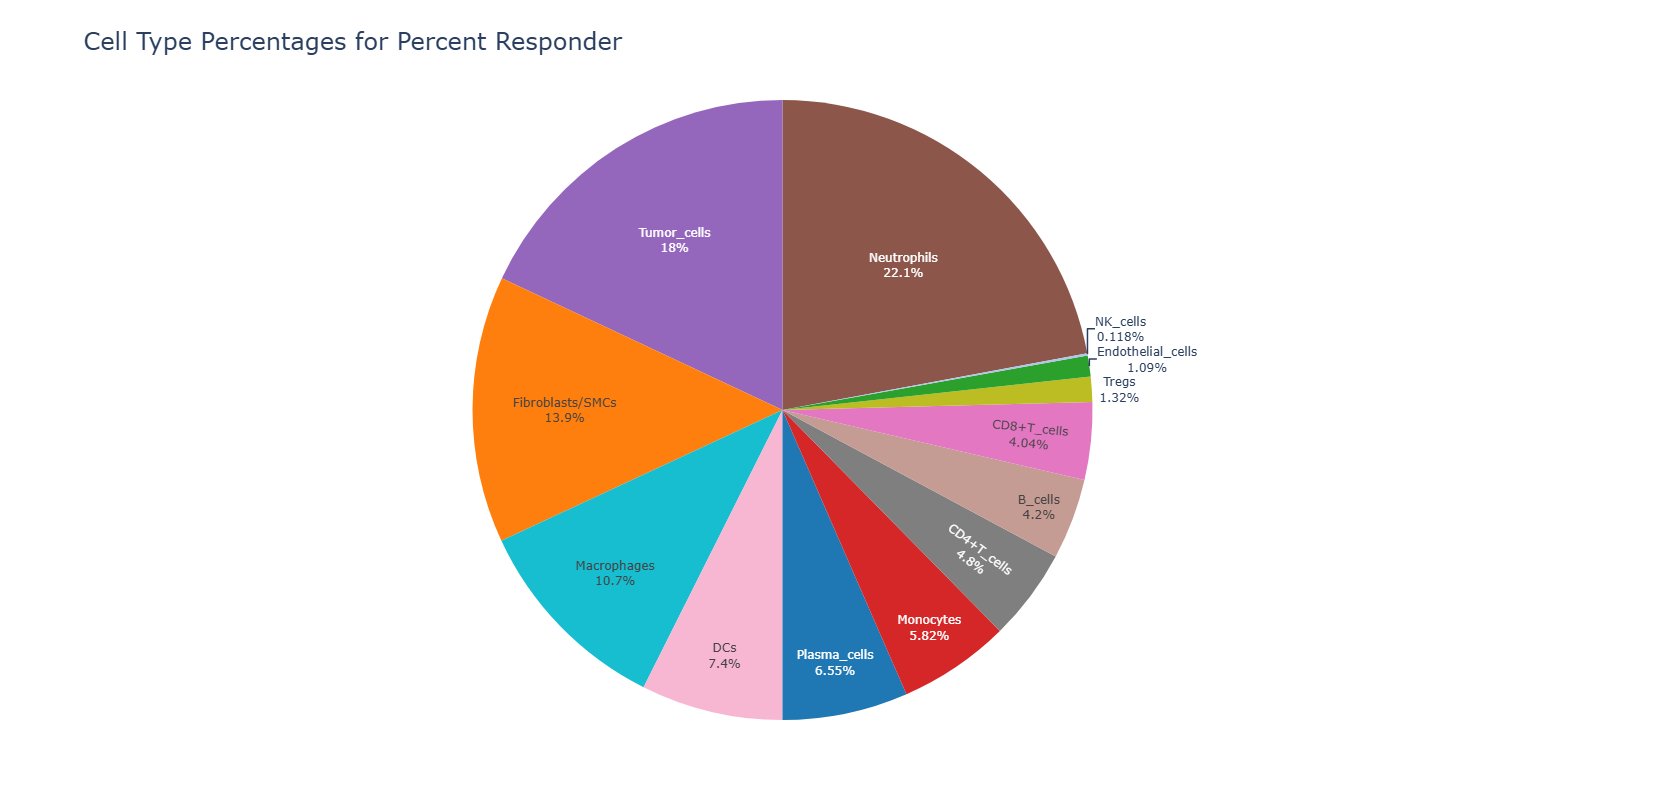

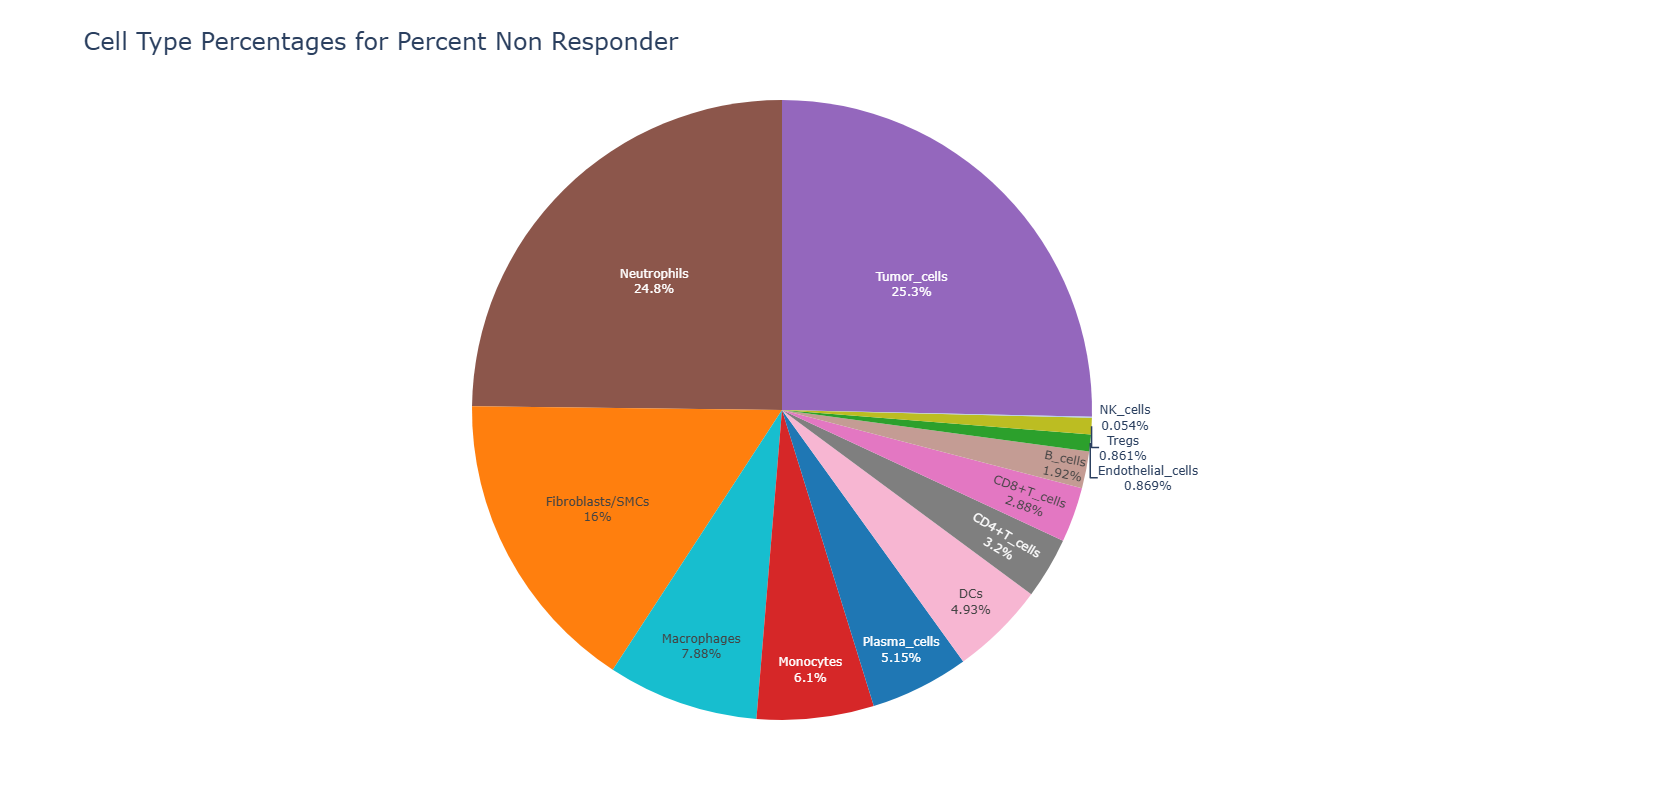

In [31]:
import importlib
import my_functions

importlib.reload(my_functions)

my_functions.plot_cell_type_pie("Percent Responder",all_total_counts_R,800,800,False,False)
my_functions.plot_cell_type_pie("Percent Non Responder",all_total_counts_NR,800,800,False,False)